Gradient Descent

Gradient Descent is an optimization algorithm used in machine learning to minimize a loss (cost) function by iteratively adjusting model parameters (like weights). The main idea is to move in the direction of the negative gradient (steepest downward slope) to reach the lowest point of the function, known as the global minimum.

In simple terms, imagine standing on a hill and trying to reach the bottom. At each step, you look at the slope around you and move downhill. Gradient Descent follows the same logic mathematically by updating parameters using the gradient (derivative) of the loss function.

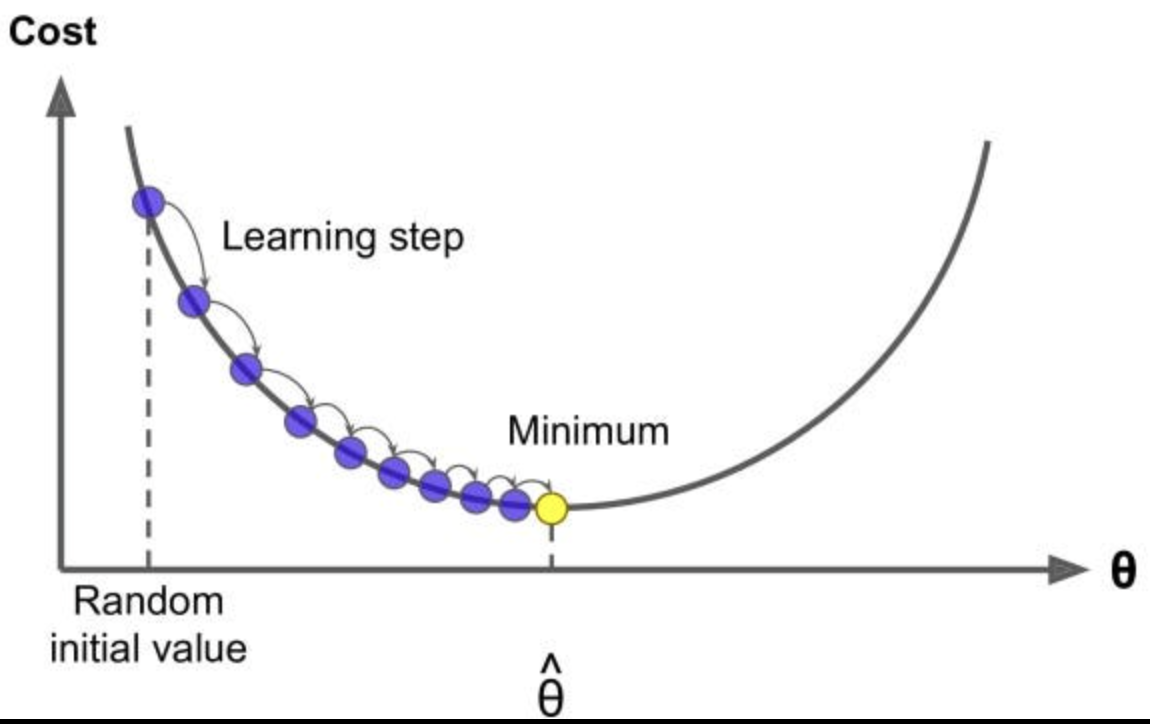

Gradient Descent is a method that iteratively moves downhill on a loss curve to find the best model parameters that minimize error.

The dataset, “Real-estate-dataset.csv,” includes housing price information based on features such as transaction date (X1), house age (X2), distance to the nearest MRT station (X3), number of convenience stores (X4), latitude (X5), and longitude (X6). The data required minimal preprocessing as it contained no missing values and all variables were numeric. A Gradient Descent-based regression model was trained on this dataset, and its performance was evaluated using parameters such as theta (model coefficients), R², RMSE, and RSE. Additionally, visualization techniques including actual vs. predicted plots and residual plots were used to assess model accuracy and error patterns.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
file_path = '/content/Real-estate-dataset.csv'
housing_df = pd.read_csv(file_path)

In [3]:
# Data Cleaning
# Remove rows based on specific conditions
#conditions = [
 #   (housing_df['bedrooms'] == 33) & (housing_df['bathrooms'] == 1.75),
#  (housing_df['bedrooms'] == 0) & (housing_df['price'] == 1095000),
#    (housing_df['bedrooms'] == 0) & (housing_df['price'] == 380000),
#    (housing_df['bedrooms'] == 33) & (housing_df['area'] == 1620),
#    (housing_df['area'] > 1000000) & (housing_df['bathrooms'] == 1)
#]
#for condition in conditions:
#    housing_df = housing_df.drop(housing_df[condition].index)

# Drop top 1% of the data from the 'price' column
rows_to_drop = int(len(housing_df) * 0.01)
housing_df = housing_df.sort_values('price', ascending=False).iloc[rows_to_drop:]
# Convert categorical 'yes'/'no' columns to numeric
#categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
#for col in categorical_cols:
 #   le = LabelEncoder()
  #  housing_df[col] = le.fit_transform(housing_df[col])

# Applying one-hot encoding to the 'furnishingstatus' column
#housing_df = pd.get_dummies(housing_df, columns=['furnishingstatus'], drop_first=True)

# Extract the features (X) and target variable (y)
X = housing_df.drop('price', axis=1).values
y = housing_df['price'].values

In [4]:
#Data Loading and Preprocessing Summary

# Normalize the data
sc_X = StandardScaler()
X_normalized = sc_X.fit_transform(X)
X_normalized = np.hstack((np.ones((X_normalized.shape[0], 1)), X_normalized)) # Add intercept term

sc_y = StandardScaler()
y_normalized = np.ravel(sc_y.fit_transform(y.reshape(-1, 1)))

# Gradient Descent Functions
def compute_cost(X, y, theta):
    m = len(y)
    J = np.sum((X.dot(theta) - y) ** 2) / (2 * m)
    return J

def gradient_function(X, y, theta):
    m = len(y)
    h = X.dot(theta)
    grad = (1 / m) * X.T.dot(h - y)
    return grad

def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []
    grad_magnitude_history = []

    for i in range(iterations):
        gradient = gradient_function(X, y, theta)
        grad_magnitude = np.linalg.norm(gradient)
        theta -= alpha * gradient
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        grad_magnitude_history.append(grad_magnitude)

    return theta, cost_history, grad_magnitude_history

# Model Training
alpha = 0.01
iterations = 1000
theta = np.zeros(X_normalized.shape[1])

theta_final, cost_history, grad_magnitude_history = gradient_descent(X_normalized, y_normalized, theta, alpha, iterations)

# Print final parameters (optional)
print("Final parameters:", theta_final)

Final parameters: [ 1.10780360e-13 -4.66192342e-02  8.02976910e-02 -2.49318474e-01
 -3.60602941e-01  2.78459664e-01  2.32239822e-01  3.90414848e-02]


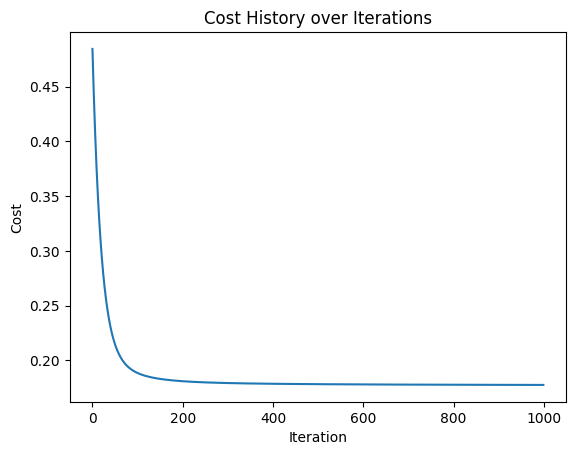

In [5]:
#Cost Function Visualization
#Plots the cost_history values generated during gradient descent, Displays how the cost decreases over iterations, helping evaluate convergence, Includes labeled axes and a title for clear interpretation of the model’s optimization progress.

import matplotlib.pyplot as plt

# Plot the cost history
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost History over Iterations')
plt.show()

Model Evaluation: The model evaluation process involves generating predictions using the normalized feature set and the optimized model parameters, followed by transforming these predictions back to the original price scale using the inverse transformation of the target scaler. Key performance metrics are then computed, including Mean Squared Error (MSE) to measure average squared prediction error, Root Mean Squared Error (RMSE) to express error in the original units, and R-squared to quantify the proportion of variance explained by the model. These metrics are reported to provide a comprehensive assessment of the model’s accuracy and overall performance.

In [6]:
# Calculate predictions on the normalized features
y_pred_normalized = X_normalized.dot(theta_final)

# Rescale the predictions back to the original scale
y_pred = sc_y.inverse_transform(y_pred_normalized.reshape(-1, 1)).flatten()

# Calculate Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

# Calculate R-squared
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R-squared:", r_squared)

Mean Squared Error: 56.7760156220555
Root Mean Squared Error: 7.534986106294789
R-squared: 0.6448723788935375


The model’s performance is further analyzed using two visualization functions. The Actual vs. Predicted plot compares predicted values with true values through a scatter plot, where alignment along the reference line indicates accurate predictions. The Residual Plot illustrates the differences between actual and predicted values, helping identify bias or systematic error patterns. Visual enhancements such as transparency, gridlines, axis labels, titles, and legends improve interpretability. Both plots are generated using the actual target values and model predictions, providing insight into prediction accuracy and error behavior.

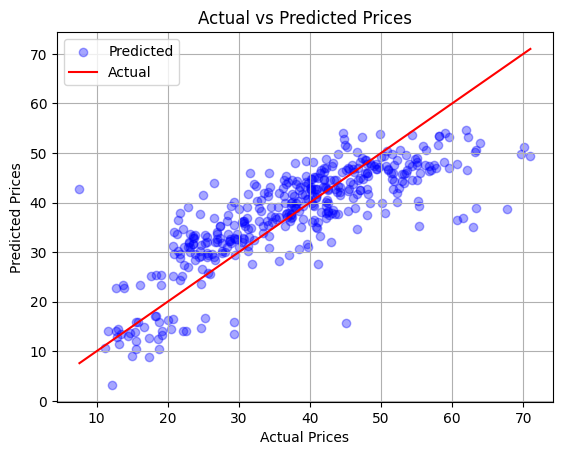

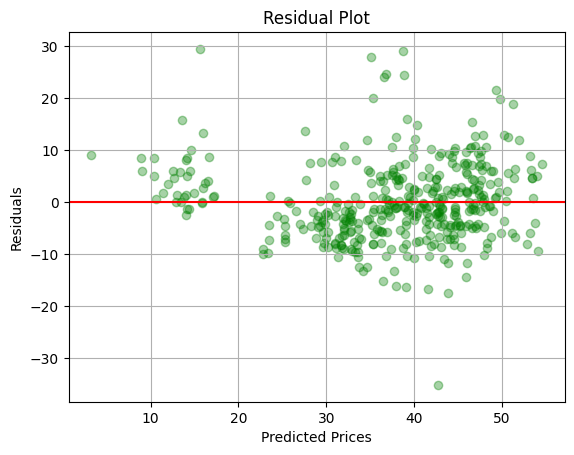

In [7]:
import matplotlib.pyplot as plt

def plot_predictions(y_test, y_pred):
    """
    Plots the actual vs predicted values.
    """
    plt.scatter(y_test, y_pred, color='blue', alpha=0.35, label='Predicted')   # transparency added
    plt.plot(y_test, y_test, color='red', label='Actual')
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title("Actual vs Predicted Prices")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_residuals(y_test, y_pred):
    """
    Plots the residuals of the model.
    """
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals, color='green', alpha=0.35)   # transparency added
    plt.axhline(y=0, color='red', linestyle='-')
    plt.title("Residual Plot")
    plt.xlabel("Predicted Prices")
    plt.ylabel("Residuals")
    plt.grid(True)
    plt.show()


# Assuming y is your actual data and y_pred is the predictions from your model
plot_predictions(y, y_pred)
plot_residuals(y, y_pred)

The gradient magnitude visualization first verifies whether gradient values have been recorded before generating the plot. It then displays the gradient magnitude across iterations using a continuous line along with semi-transparent scatter points for improved clarity. This visualization helps assess the convergence behavior of the gradient descent algorithm, as a decreasing trend in gradient magnitude indicates progress toward an optimal solution. The plot is enhanced with labeled axes, a title, gridlines, and a legend for better interpretability, and a message is displayed if no gradient history is available.

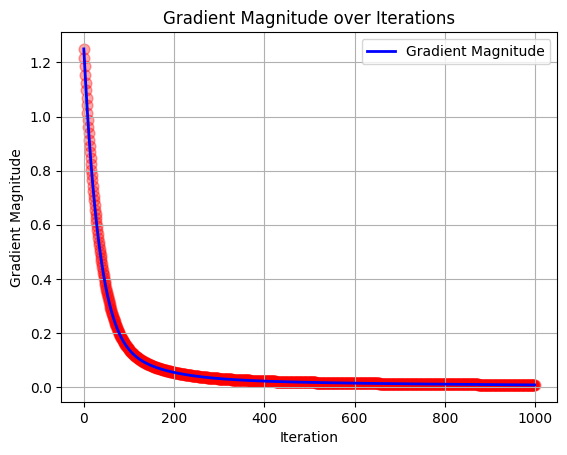

In [8]:
import matplotlib.pyplot as plt

# Check if grad_magnitude_history is not empty
if grad_magnitude_history:
    iterations = range(len(grad_magnitude_history))

    # Solid line
    plt.plot(iterations, grad_magnitude_history, color='b', linewidth=2, label="Gradient Magnitude")

    # Transparent dots
    plt.scatter(iterations, grad_magnitude_history, color='red', alpha=0.35, s=60)

    plt.xlabel('Iteration')
    plt.ylabel('Gradient Magnitude')
    plt.title('Gradient Magnitude over Iterations')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("The grad_magnitude_history list is empty.")


Final Conclusion

The end-to-end workflow effectively applied gradient descent for housing price prediction, encompassing data loading, preprocessing, and normalization. Convergence behavior was validated through cost and gradient magnitude trends, both indicating stable optimization across iterations. After transforming predictions back to the original scale, evaluation metrics such as MSE, RMSE, and R² confirmed the model’s ability to capture underlying relationships in the data. Further validation through actual vs. predicted and residual analyses demonstrated consistent performance and highlighted potential areas for improvement. Overall, the gradient descent model proved to be a reliable and interpretable approach, providing meaningful insights into prediction accuracy, error distribution, and optimization dynamics.